## Decoding Customer Value
### SQL-Driven Retention Strategy for a D2C Fashion Brand

##### **By :** Sanchita Gupta, Harsh Gupta 
---

In [1]:
# Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

plt.style.use('ggplot')

In [3]:
# Load Dataset
df = pd.read_csv(r'..\data\raw\Dataset.csv')
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


## BASIC DATASET OVERVIEW

**Objective**: Understand the structure, size, and overall composition of the dataset before beginning analysis.

In [ ]:
print("Shape of Dataset :", df.shape)
df.columns.tolist()

Shape of Dataset : (3900, 18)


['Customer ID',
 'Age',
 'Gender',
 'Item Purchased',
 'Category',
 'Purchase Amount (USD)',
 'Location',
 'Size',
 'Color',
 'Season',
 'Review Rating',
 'Subscription Status',
 'Shipping Type',
 'Discount Applied',
 'Promo Code Used',
 'Previous Purchases',
 'Payment Method',
 'Frequency of Purchases']

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [ ]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3863.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750065,25.351538
std,1125.977353,15.207589,23.685392,0.716983,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [ ]:
# Statistical Summary Including Categorical Columns
df.describe(include='all')

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3863.000000,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,675,2223,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.750065,NaN,NaN,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.716983,NaN,NaN,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


## Missing Values and Duplicates Analysis 

 **Why This Matters**: Data quality issues such as missing values or duplicates can affect downstream analysis and customer insights.

In [ ]:
# Missing Value Analysis
missing_values = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': (df.isnull().sum()/len(df))*100
})

missing_values.sort_values(by='Missing Values', ascending=False)

,Missing Values,Percentage
Review Rating,37,0.948718
Customer ID,0,0.000000
Age,0,0.000000
Payment Method,0,0.000000
Previous Purchases,0,0.000000
Promo Code Used,0,0.000000
Discount Applied,0,0.000000
Shipping Type,0,0.000000
Subscription Status,0,0.000000
Season,0,0.000000


In [ ]:
# Handle Missing Review ratings 

df['Review Rating'].fillna(
    df['Review Rating'].median(),
    inplace=True
)

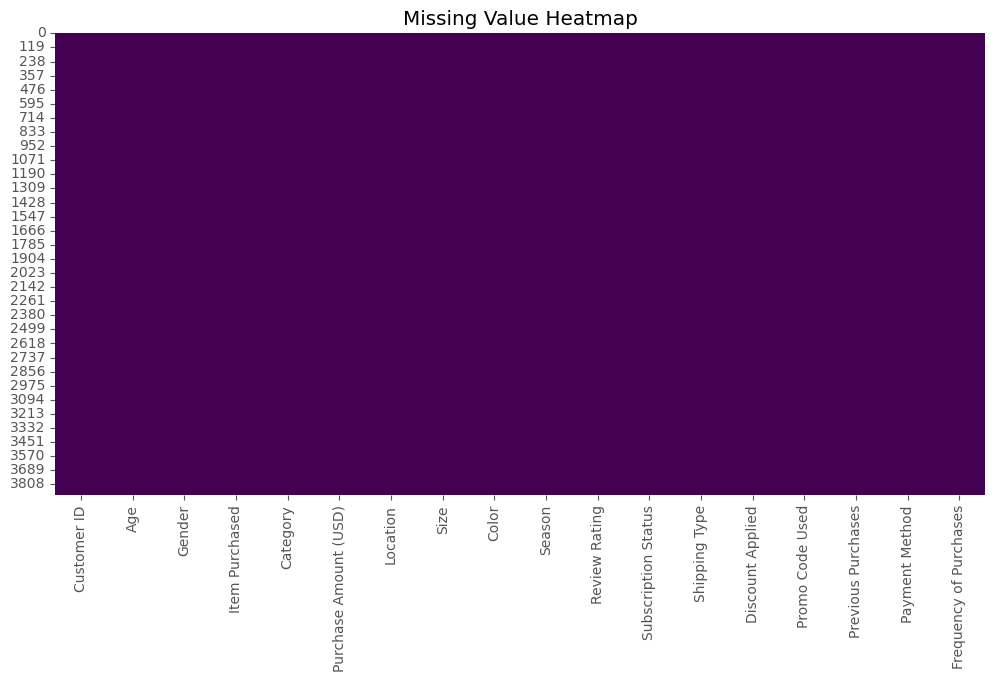

In [ ]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')

plt.title('Missing Value Heatmap')
plt.show()

In [ ]:
# Duplicate Analysis
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [ ]:
# Data Type Analysis

numerical_cols = [
    'Age',
    'Purchase Amount (USD)',
    'Review Rating',
    'Previous Purchases'
]

categorical_cols = [
    col for col in df.columns
    if col not in numerical_cols + ['Customer ID']
]

print("Numerical Columns:\n", numerical_cols)
print("\nCategorical Columns:\n", categorical_cols)

Numerical Columns:
 ['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']

Categorical Columns:
 ['Gender', 'Item Purchased', 'Category', 'Location', 'Size', 'Color', 'Season', 'Subscription Status', 'Shipping Type', 'Discount Applied', 'Promo Code Used', 'Payment Method', 'Frequency of Purchases']


## UNIVARIATE ANALYSIS - NUMERICAL FEATURES

**Objective**: Analyze the distribution of individual variables to understand customer behavior, spending patterns, and dataset characteristics.

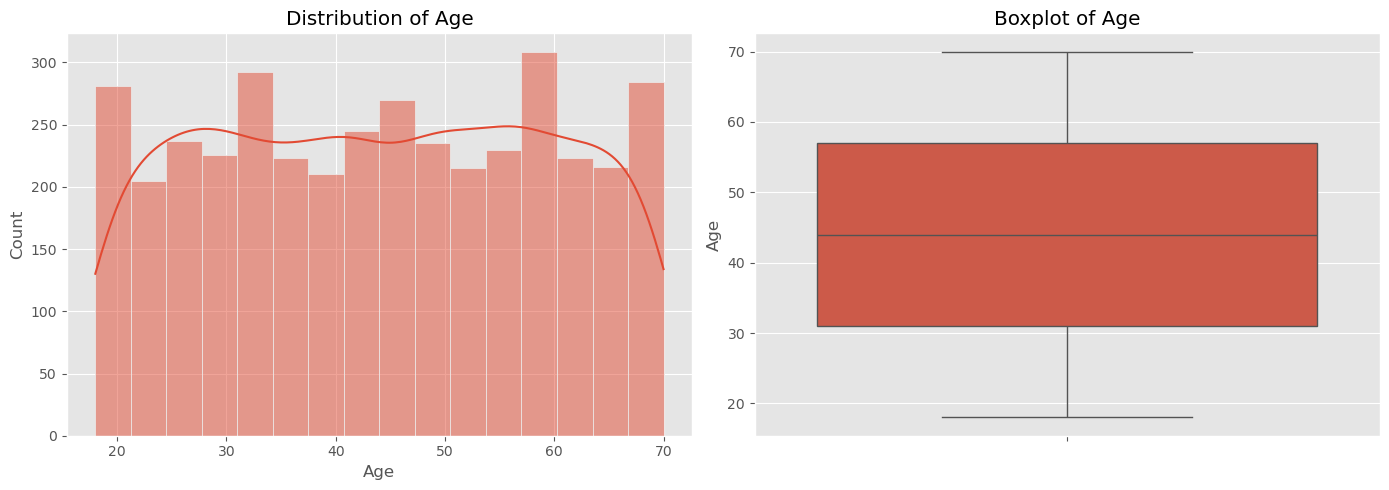

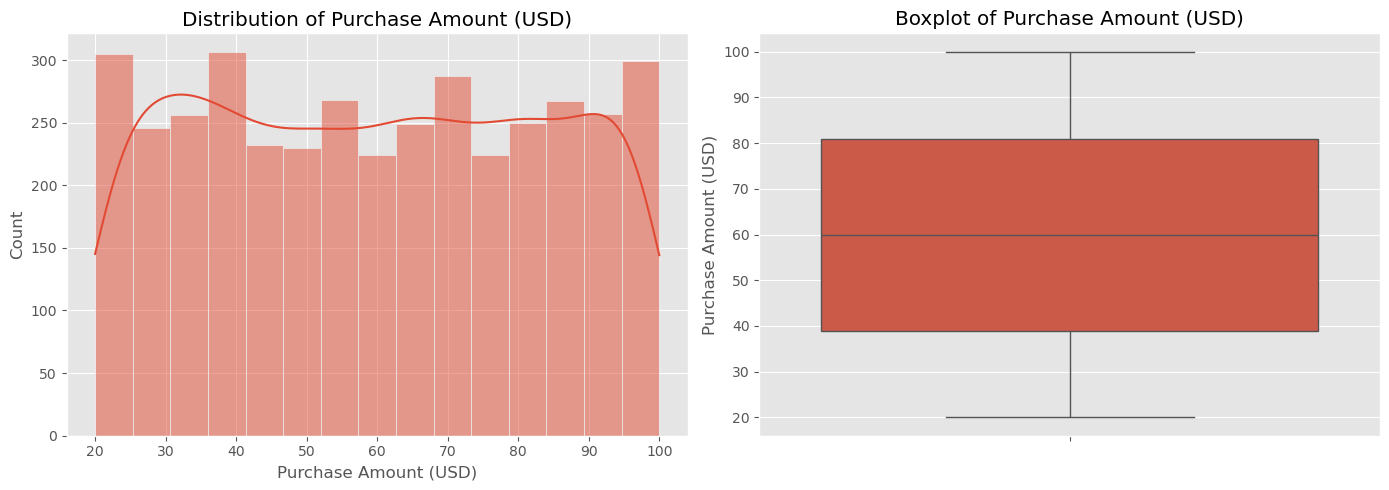

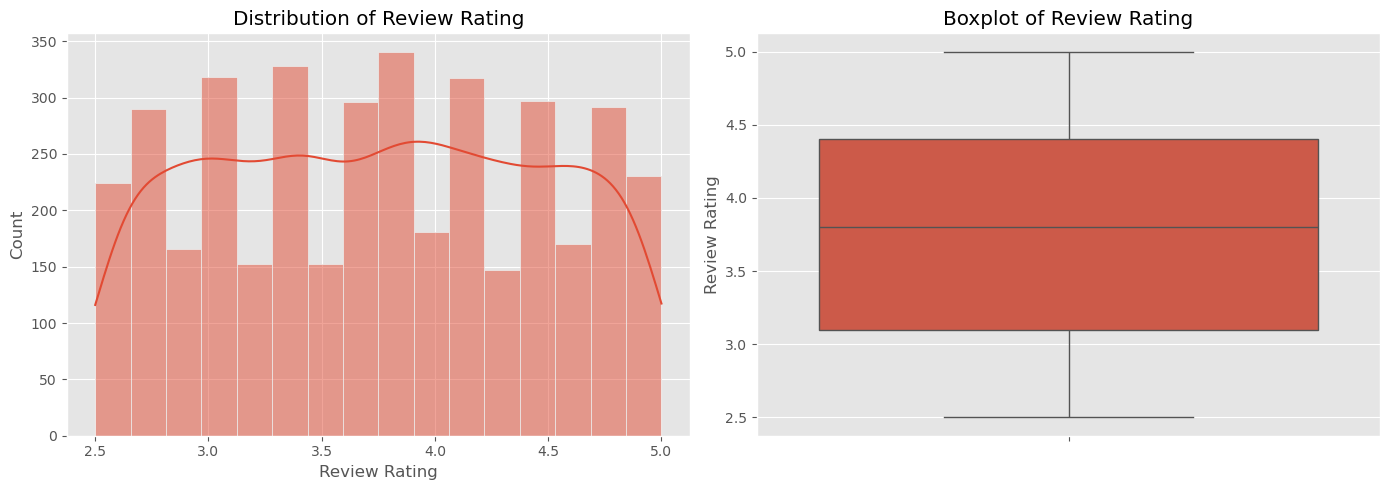

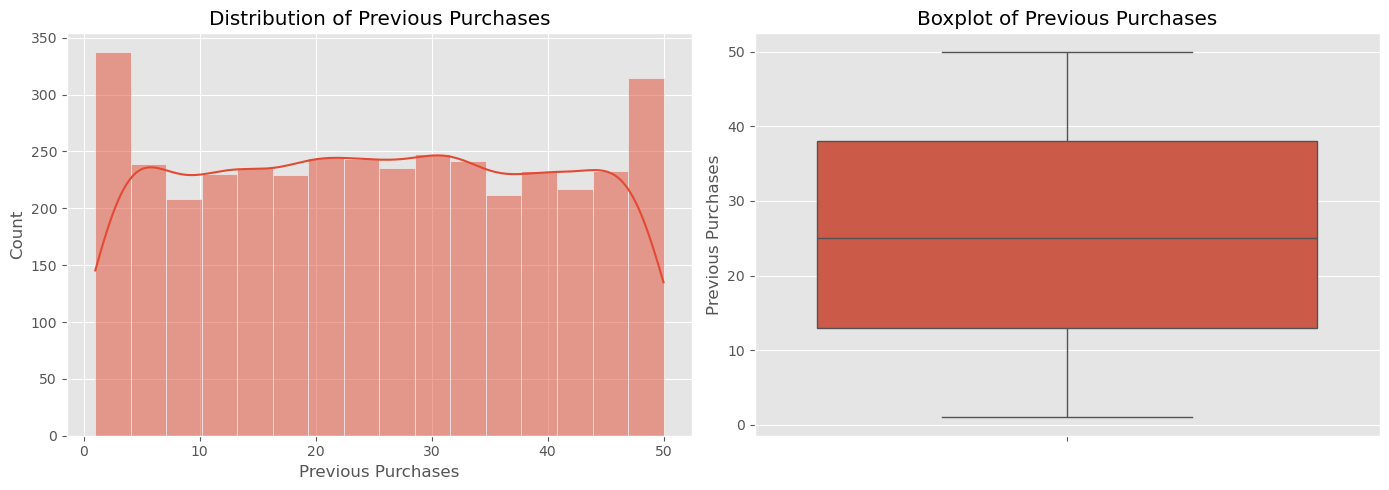

In [ ]:
for col in numerical_cols:
    
    fig, ax = plt.subplots(1,2, figsize=(14,5))
    
    sns.histplot(df[col], kde=True, ax=ax[0])
    ax[0].set_title(f'Distribution of {col}')
    
    sns.boxplot(df[col], ax=ax[1])
    ax[1].set_title(f'Boxplot of {col}')
    
    plt.tight_layout()
    plt.show()

## UNIVARIATE ANALYSIS - CATEGORICAL FEATURES

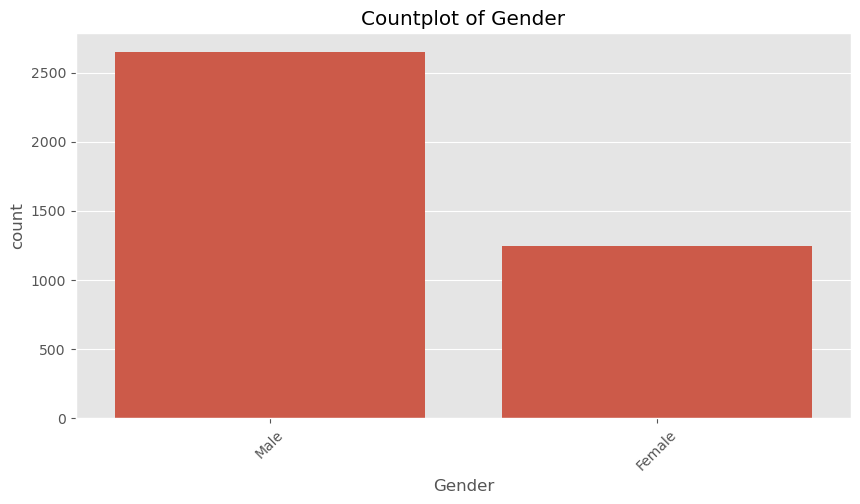

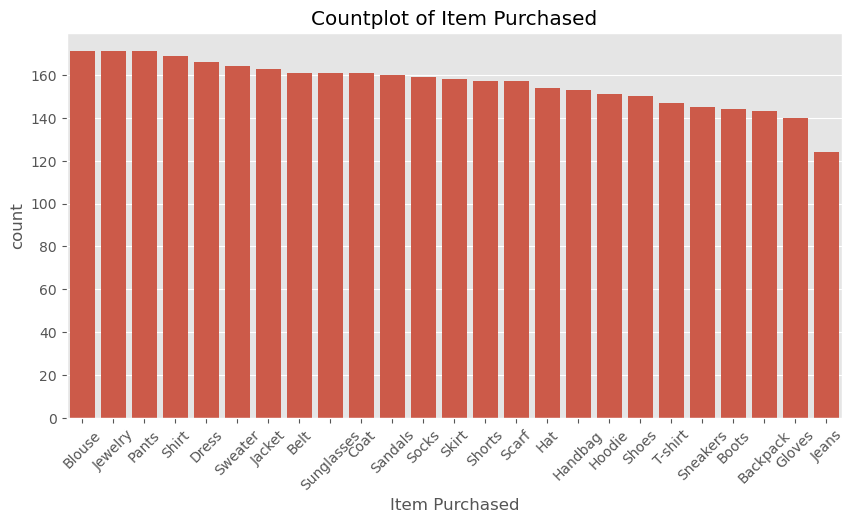

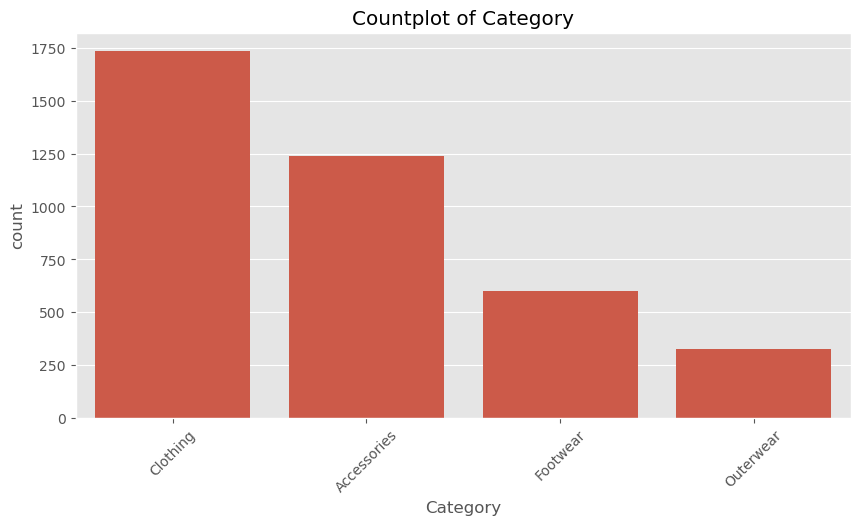

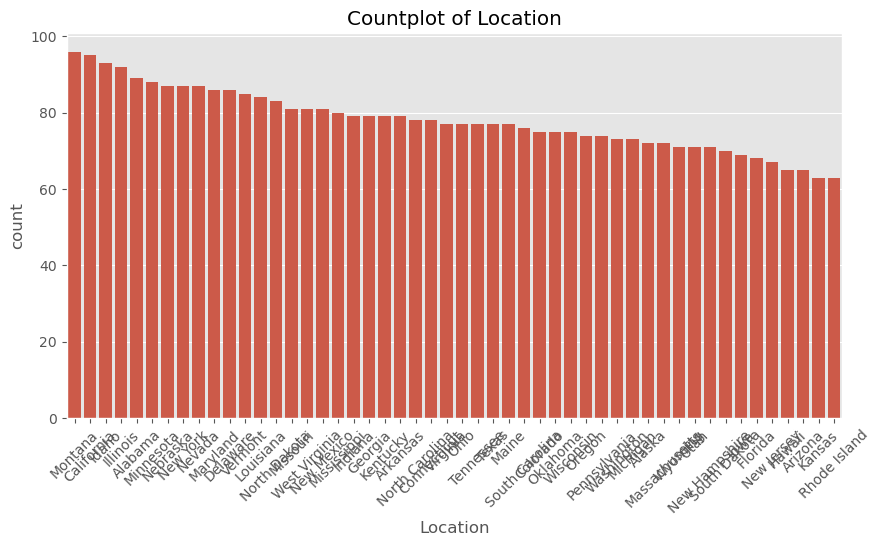

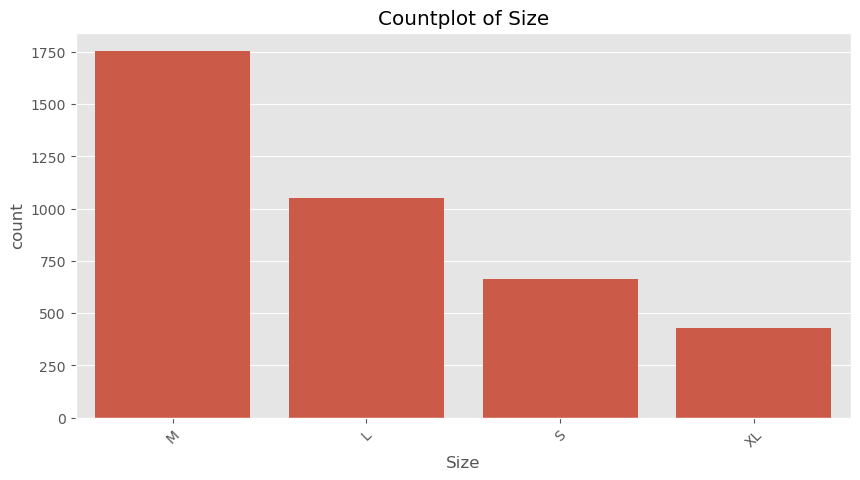

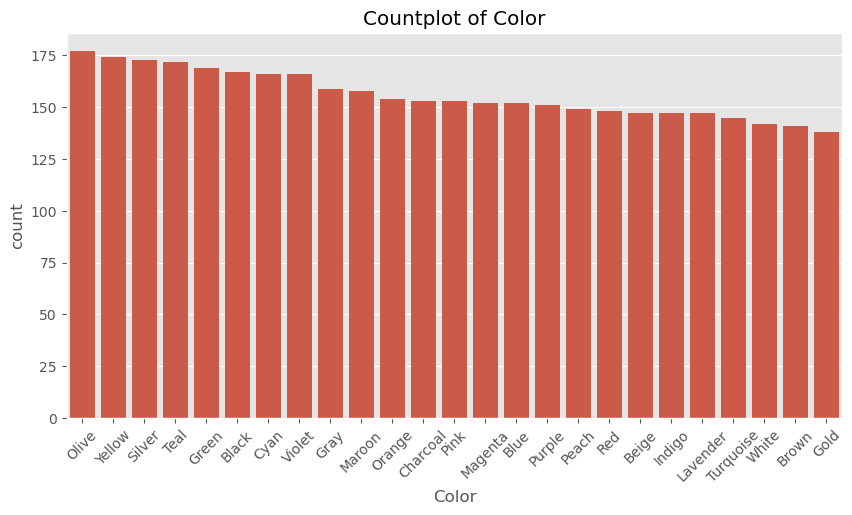

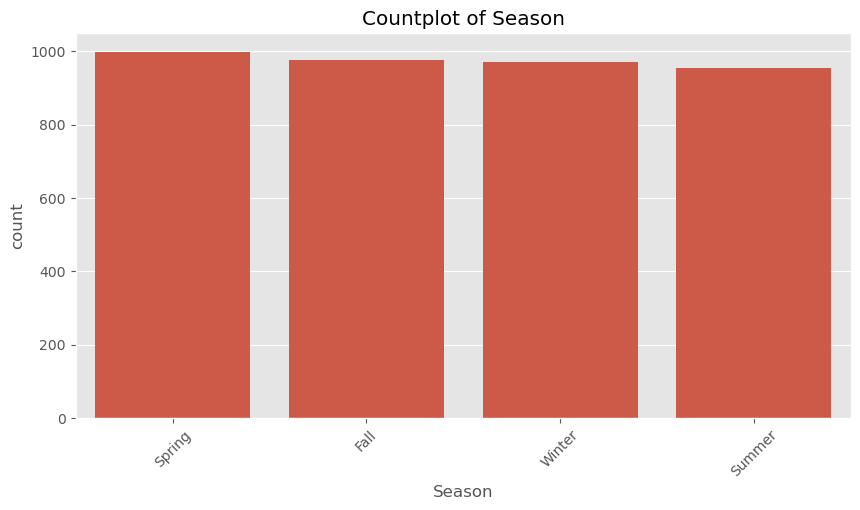

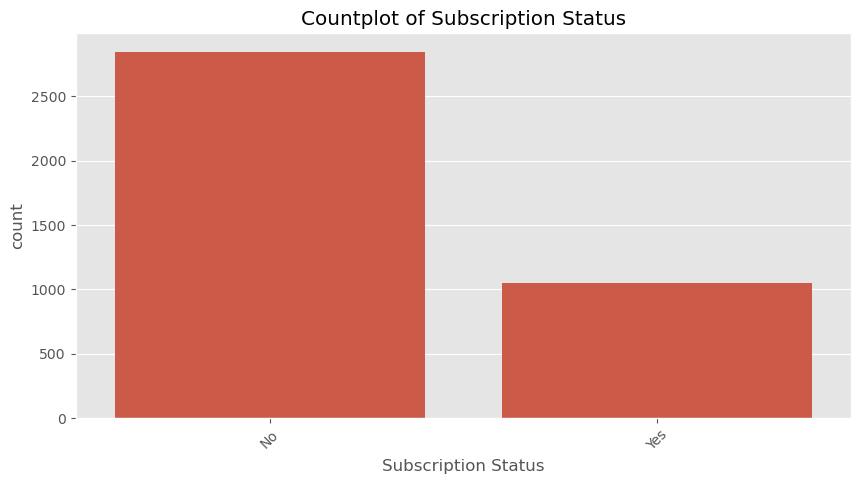

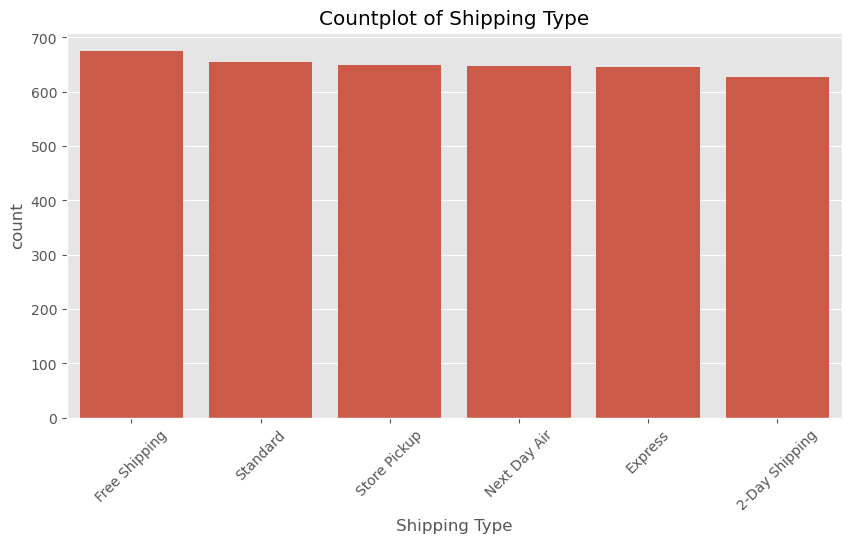

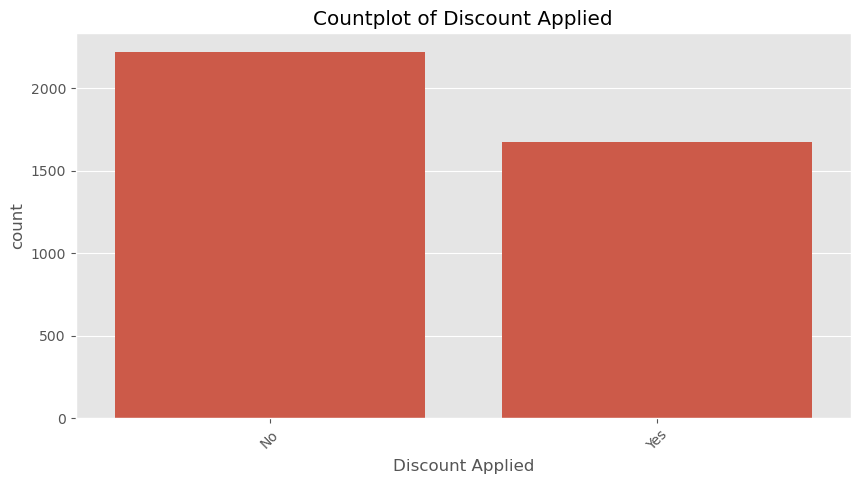

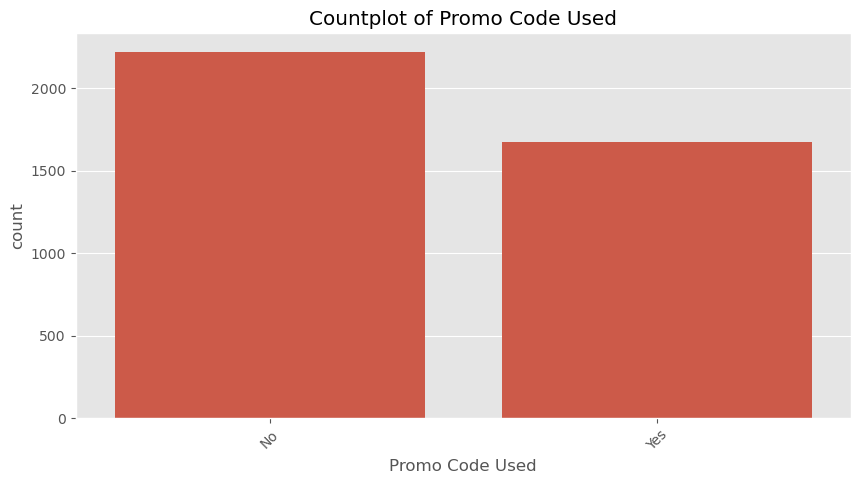

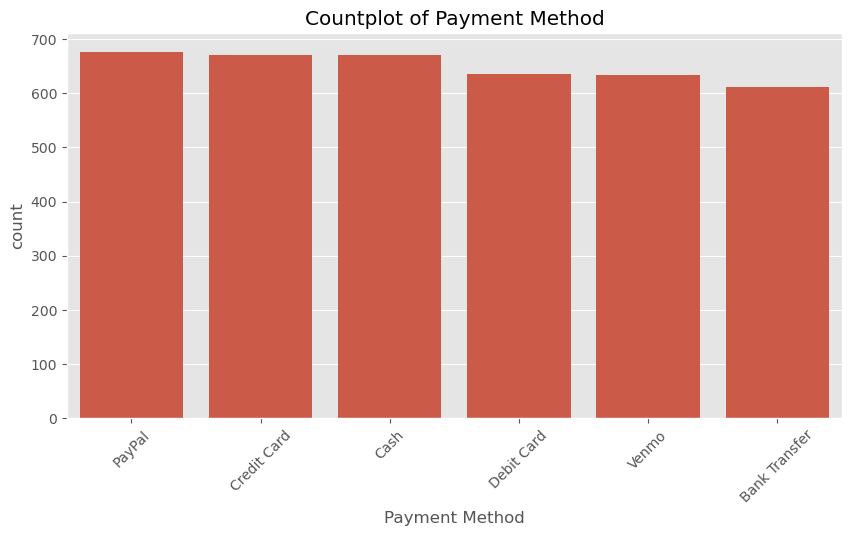

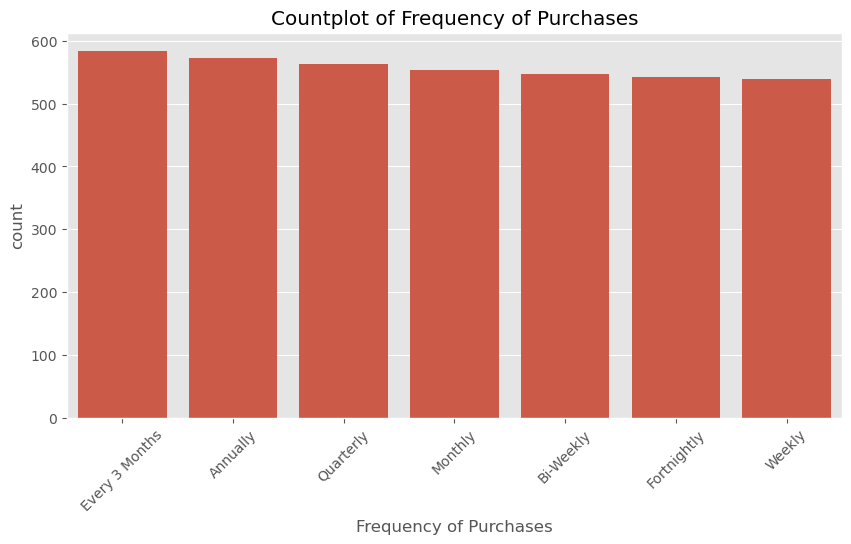

In [ ]:
for col in categorical_cols:
    
    plt.figure(figsize=(10,5))
    
    order = df[col].value_counts().index
    
    sns.countplot(data=df, x=col, order=order)
    
    plt.xticks(rotation=45)
    plt.title(f'Countplot of {col}')
    
    plt.show()

## CUSTOMER DEMOGRAPHIC ANALYSIS

**Why This Matters**: Customer demographics help identify which customer groups contribute most to revenue and loyalty.

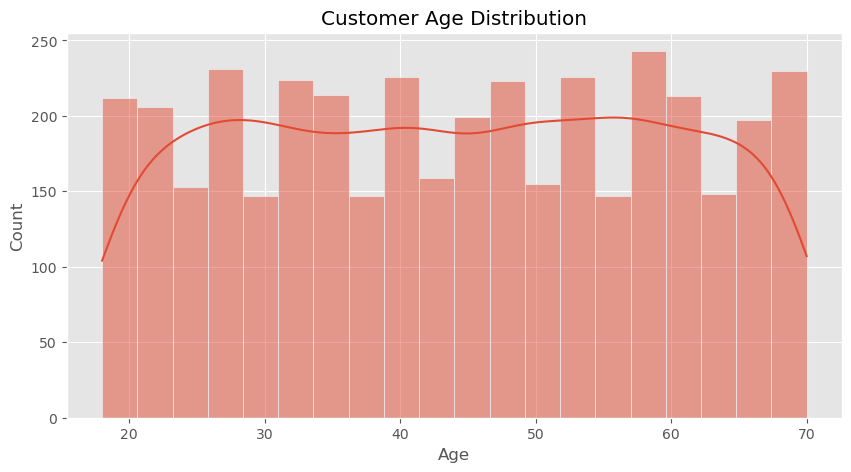

In [ ]:
# Age Distribution
plt.figure(figsize=(10,5))

sns.histplot(df['Age'], bins=20, kde=True)

plt.title('Customer Age Distribution')
plt.show()

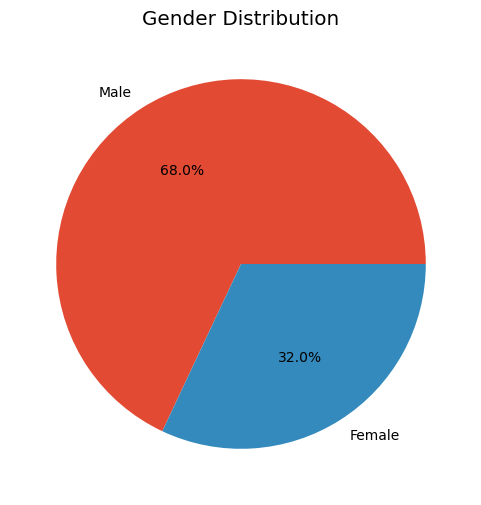

In [ ]:
# Gender Distribution
gender_counts = df['Gender'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%'
)

plt.title('Gender Distribution')
plt.show()

## PURCHASE ANALYSIS

**Objective**: Understand spending behavior across customers, locations, and purchasing patterns.

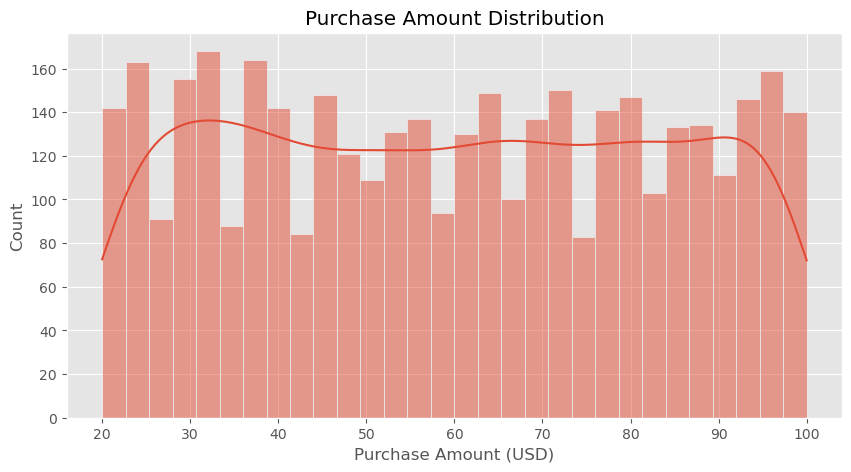

In [ ]:
# Purchase Amount Distribution

plt.figure(figsize=(10,5))

sns.histplot(df['Purchase Amount (USD)'], bins=30, kde=True)

plt.title('Purchase Amount Distribution')
plt.show()

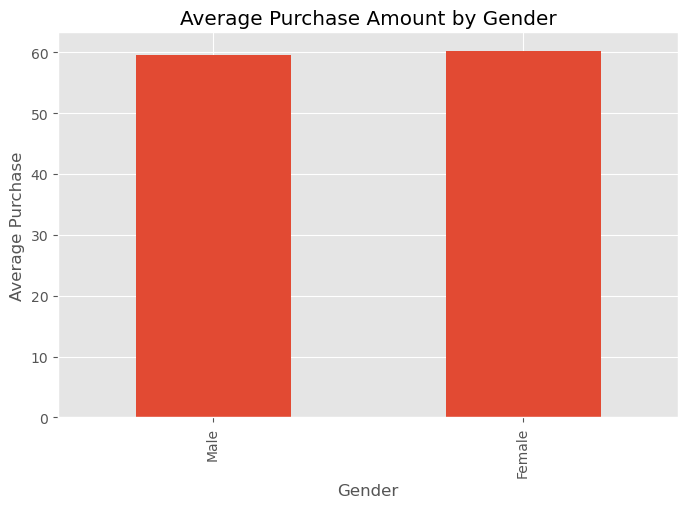

In [ ]:
# Average Purchase by Gender

avg_purchase_gender = df.groupby('Gender')['Purchase Amount (USD)'].mean().sort_values()

avg_purchase_gender.plot(kind='bar', figsize=(8,5))

plt.title('Average Purchase Amount by Gender')
plt.ylabel('Average Purchase')
plt.show()

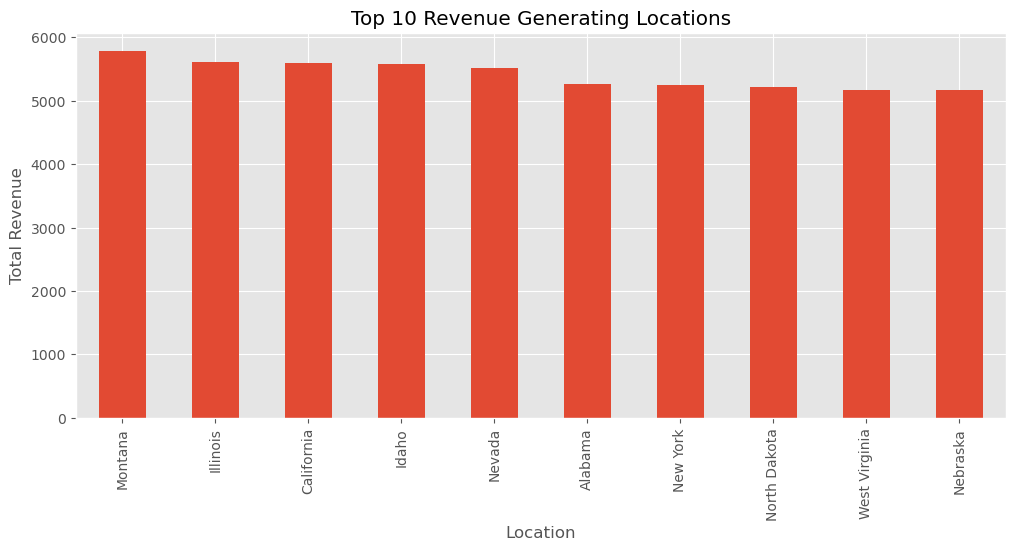

In [ ]:
# Top Spending Locations
top_locations = df.groupby('Location')['Purchase Amount (USD)'].sum().sort_values(ascending=False).head(10)

top_locations.plot(kind='bar', figsize=(12,5))

plt.title('Top 10 Revenue Generating Locations')
plt.ylabel('Total Revenue')
plt.show()

## CATEGORY ANALYSIS

**Why This Matters**: Product categories may influence customer retention, repeat behavior, and long-term value.

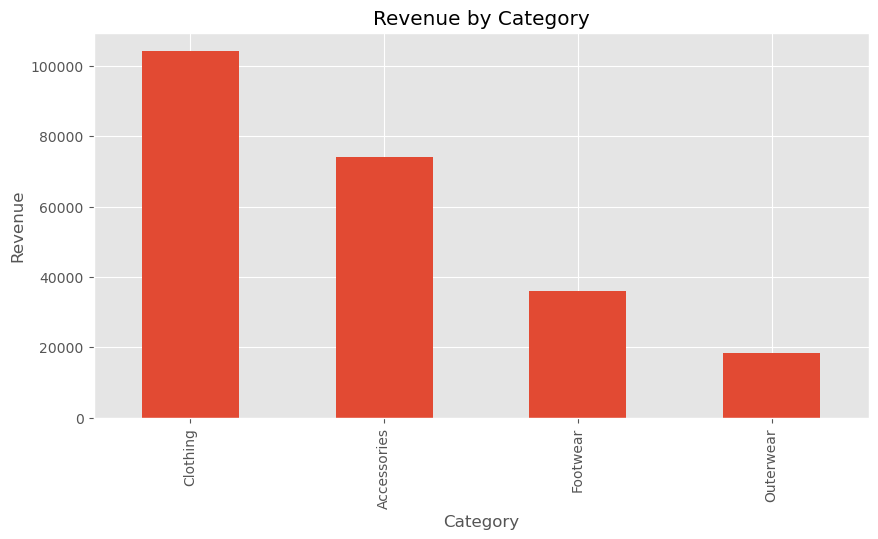

In [ ]:
# Revenue by Category
category_revenue = df.groupby('Category')['Purchase Amount (USD)'].sum().sort_values(ascending=False)

category_revenue.plot(kind='bar', figsize=(10,5))

plt.title('Revenue by Category')
plt.ylabel('Revenue')
plt.show()

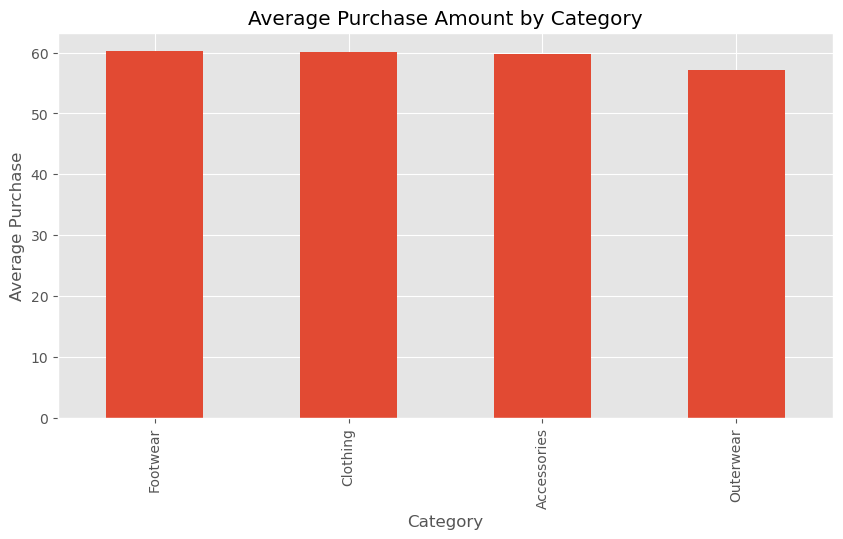

In [ ]:
# Average Purchase by Category
avg_category_purchase = df.groupby('Category')['Purchase Amount (USD)'].mean().sort_values(ascending=False)

avg_category_purchase.plot(kind='bar', figsize=(10,5))

plt.title('Average Purchase Amount by Category')
plt.ylabel('Average Purchase')
plt.show()

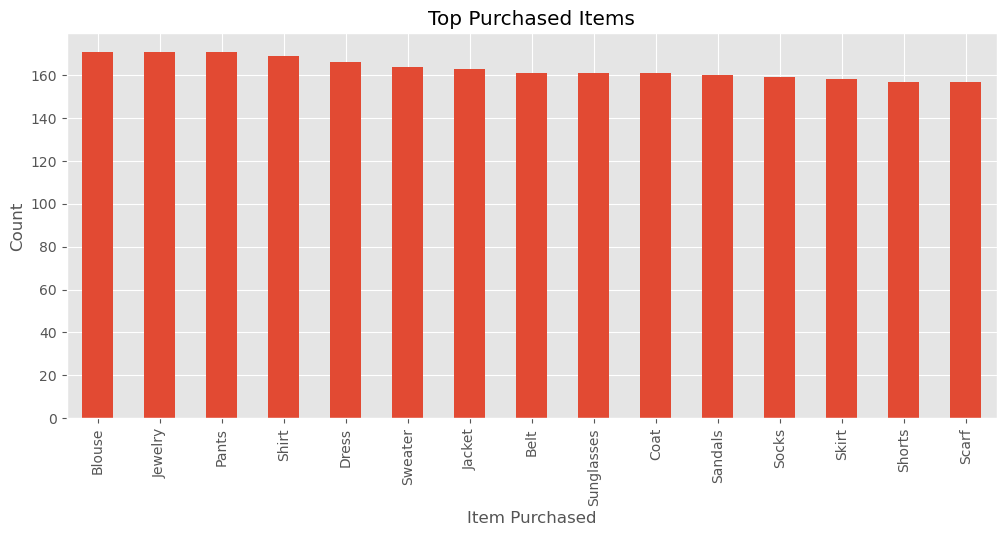

In [ ]:
# Most Purchased Items
top_items = df['Item Purchased'].value_counts().head(15)

top_items.plot(kind='bar', figsize=(12,5))

plt.title('Top Purchased Items')
plt.ylabel('Count')
plt.show()

## PROMOTION & DISCOUNT ANALYSIS

**Why This Matters**: The project’s core business problem revolves around understanding promotional dependency and its impact on customer loyalty.

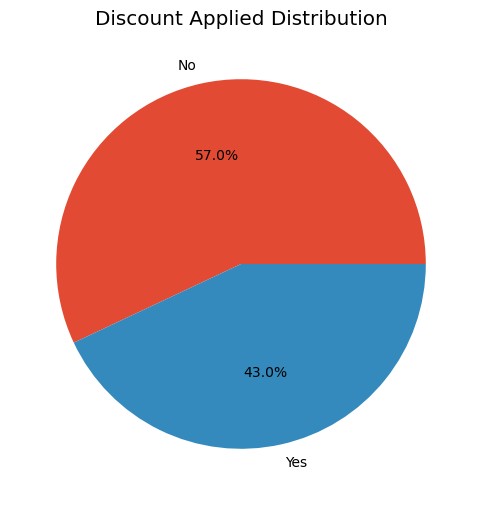

In [ ]:
# Discount Applied Distribution
discount_counts = df['Discount Applied'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    discount_counts,
    labels=discount_counts.index,
    autopct='%1.1f%%'
)

plt.title('Discount Applied Distribution')
plt.show()

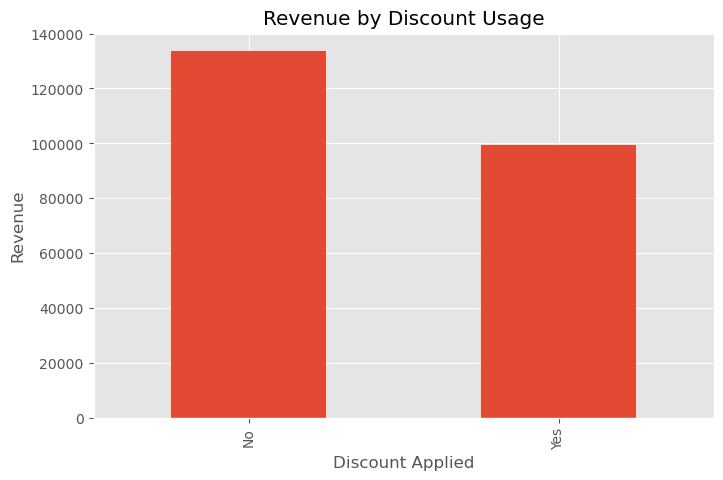

In [ ]:
# Revenue from Discount vs Non-Discount Purchases
discount_revenue = df.groupby('Discount Applied')['Purchase Amount (USD)'].sum()

discount_revenue.plot(kind='bar', figsize=(8,5))

plt.title('Revenue by Discount Usage')
plt.ylabel('Revenue')
plt.show()

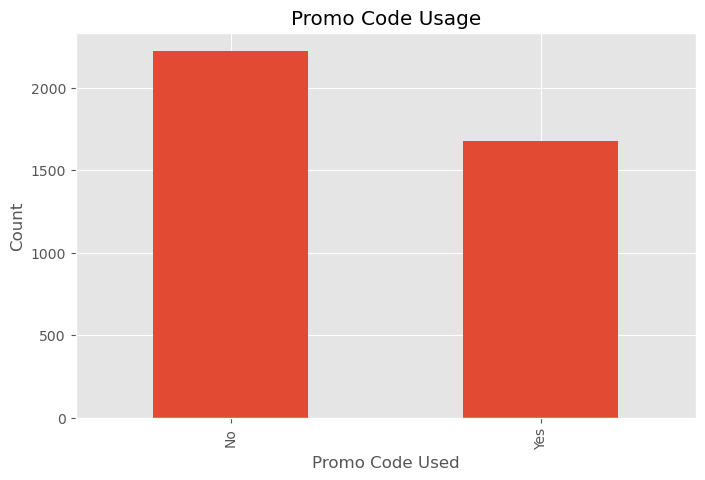

In [ ]:
# Promo Code Usage
promo_counts = df['Promo Code Used'].value_counts()

promo_counts.plot(kind='bar', figsize=(8,5))

plt.title('Promo Code Usage')
plt.ylabel('Count')
plt.show()

## LOYALTY & RETENTION ANALYSIS

**Objective**: Explore behavioral indicators that may signal customer loyalty and long-term engagement.

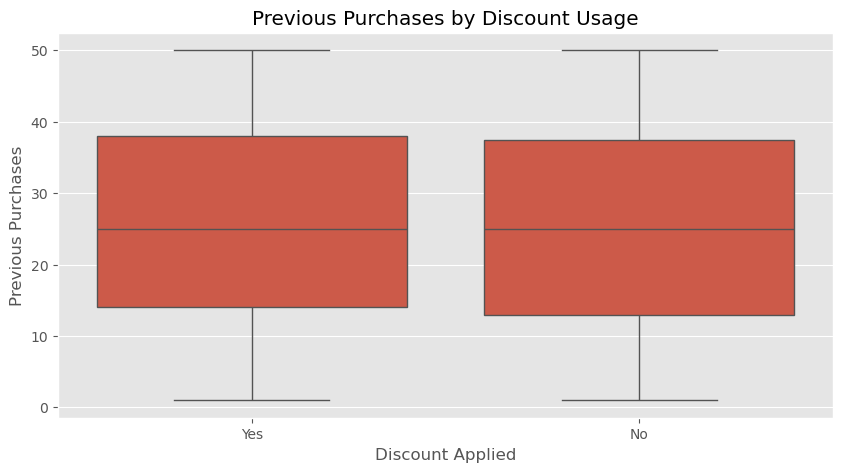

In [ ]:
# Previous Purchases by Discount Usage
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x='Discount Applied',
    y='Previous Purchases'
)

plt.title('Previous Purchases by Discount Usage')

plt.show()

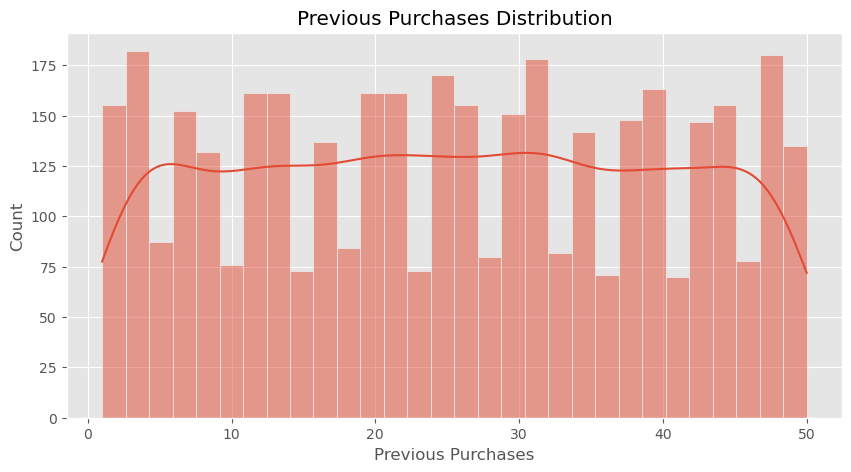

In [ ]:
# Previous Purchases Distribution
plt.figure(figsize=(10,5))

sns.histplot(df['Previous Purchases'], bins=30, kde=True)

plt.title('Previous Purchases Distribution')
plt.show()

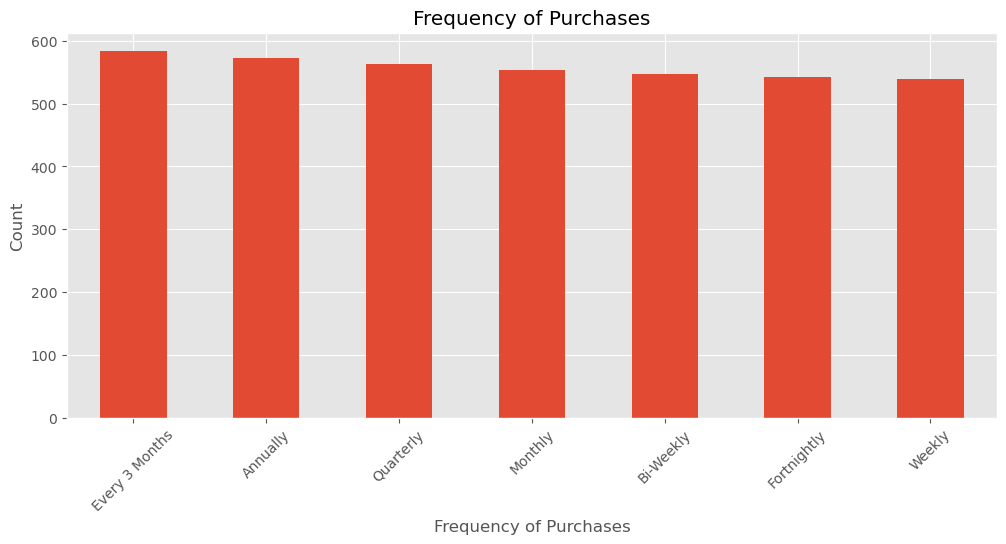

In [ ]:
# Frequency of Purchases
purchase_frequency = df['Frequency of Purchases'].value_counts()

purchase_frequency.plot(kind='bar', figsize=(12,5))

plt.title('Frequency of Purchases')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

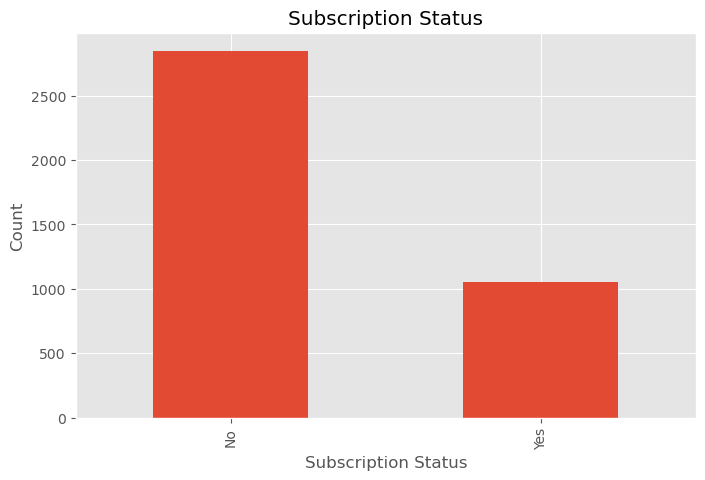

In [ ]:
# Subscription Status Analysis
subscription_counts = df['Subscription Status'].value_counts()

subscription_counts.plot(kind='bar', figsize=(8,5))

plt.title('Subscription Status')
plt.ylabel('Count')
plt.show()

## CUSTOMER SATISFACTION ANALYSIS

**Why This Matters**: Customer satisfaction can influence retention, repeat purchases, and overall customer value.

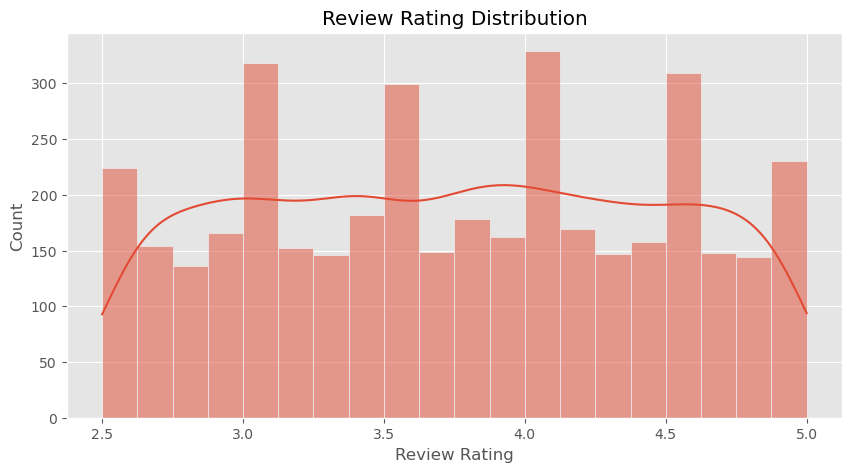

In [ ]:
# Review Rating Distribution
plt.figure(figsize=(10,5))

sns.histplot(df['Review Rating'], bins=20, kde=True)

plt.title('Review Rating Distribution')
plt.show()

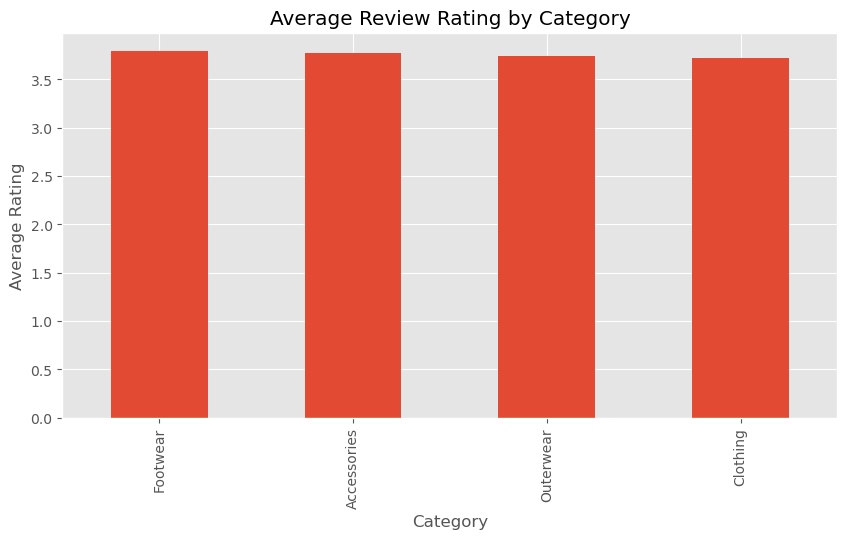

In [ ]:
# Average Review Rating by Category
avg_review_category = df.groupby('Category')['Review Rating'].mean().sort_values(ascending=False)

avg_review_category.plot(kind='bar', figsize=(10,5))

plt.title('Average Review Rating by Category')
plt.ylabel('Average Rating')
plt.show()

## SHIPPING & PAYMENT ANALYSIS

**Objective**: Analyze operational and purchasing preferences that may differentiate customer segments.

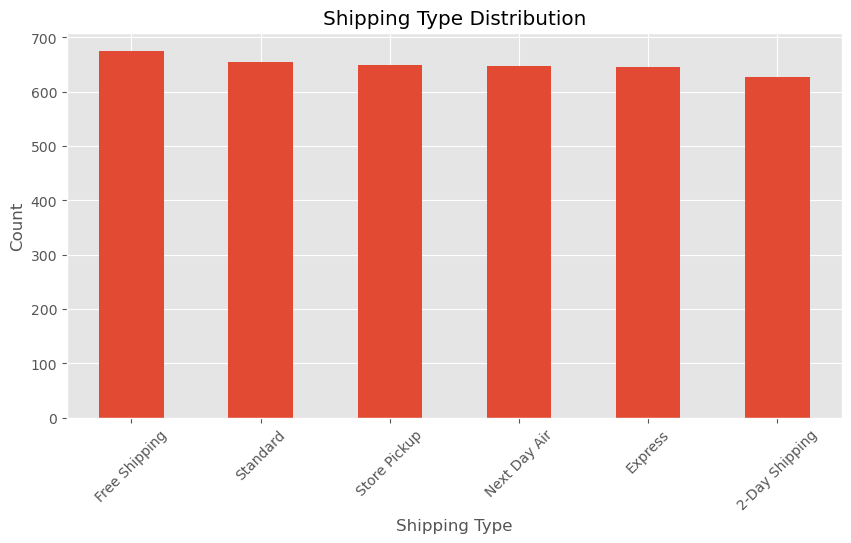

In [ ]:
# Shipping Type Analysis
shipping_counts = df['Shipping Type'].value_counts()

shipping_counts.plot(kind='bar', figsize=(10,5))

plt.title('Shipping Type Distribution')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

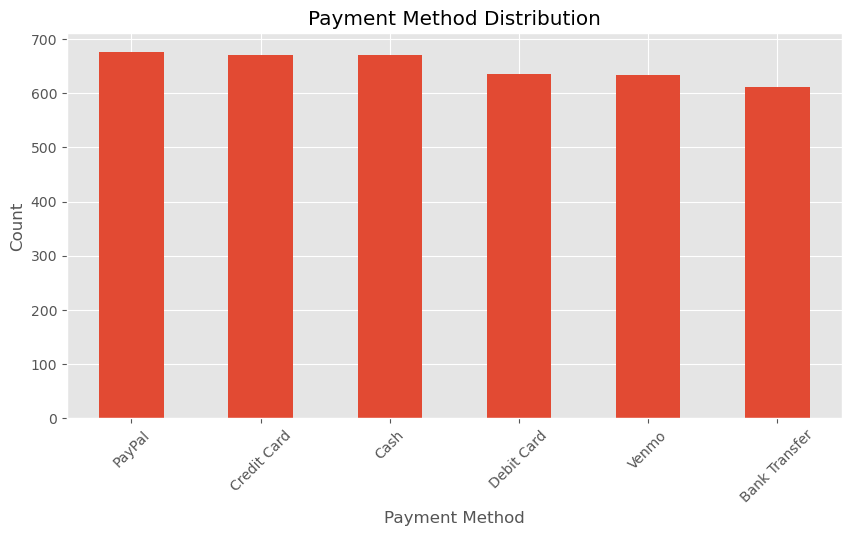

In [ ]:
# Payment Method Analysis
payment_counts = df['Payment Method'].value_counts()

payment_counts.plot(kind='bar', figsize=(10,5))

plt.title('Payment Method Distribution')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

## BIVARIATE ANALYSIS

**Objective**: Study relationships between key variables to identify patterns influencing customer value and loyalty.

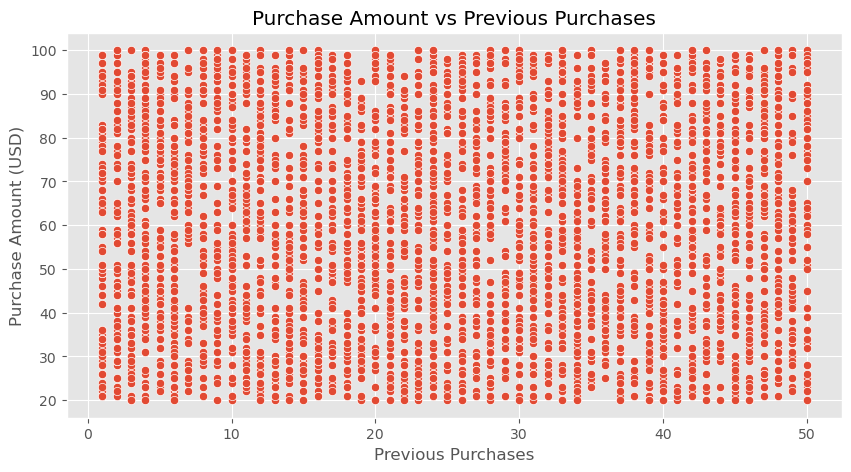

In [ ]:
# Purchase Amount vs Previous Purchases
plt.figure(figsize=(10,5))

sns.scatterplot(
    data=df,
    x='Previous Purchases',
    y='Purchase Amount (USD)'
)

plt.title('Purchase Amount vs Previous Purchases')
plt.show()

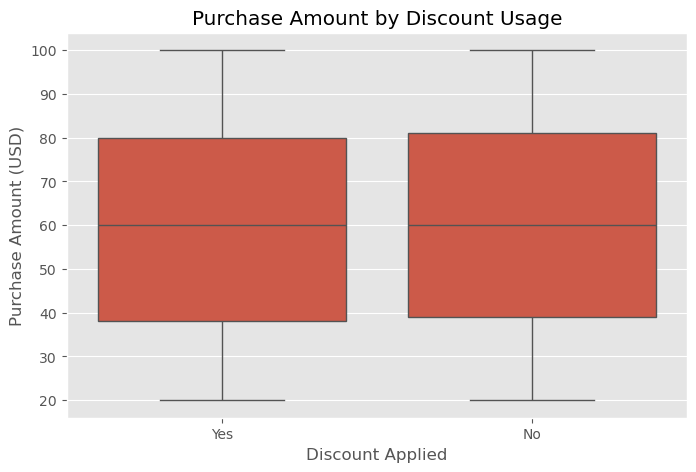

In [ ]:
# Purchase Amount by Discount Usage
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Discount Applied',
    y='Purchase Amount (USD)'
)

plt.title('Purchase Amount by Discount Usage')
plt.show()

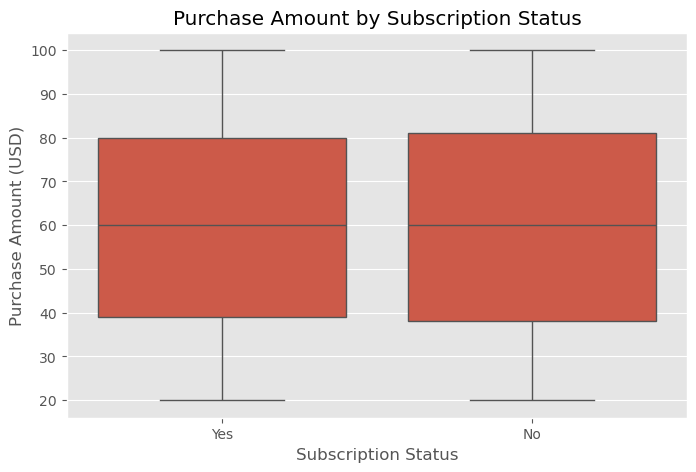

In [ ]:
# Purchase Amount by Subscription Status
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Subscription Status',
    y='Purchase Amount (USD)'
)

plt.title('Purchase Amount by Subscription Status')
plt.show()

## CORRELATION ANALYSIS

Correlation analysis helps identify linear relationships between numerical variables, though many important business signals in this dataset are categorical.

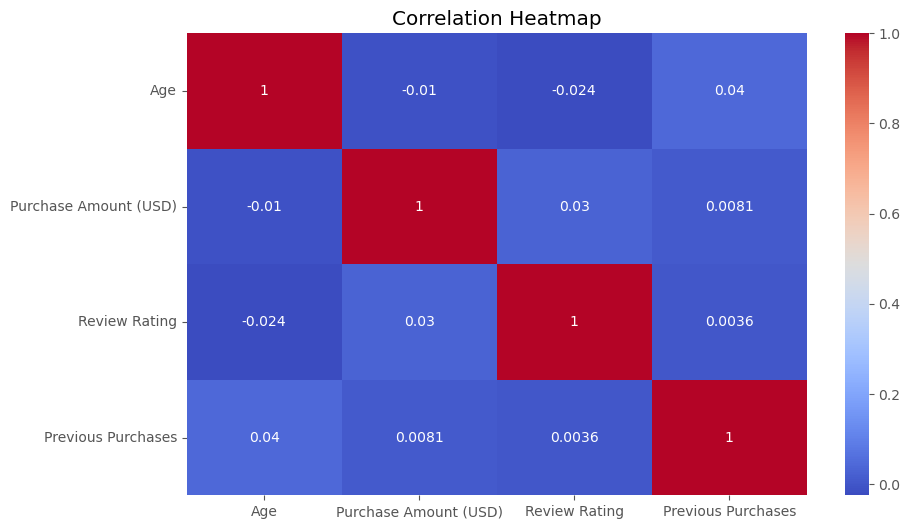

In [ ]:
corr = df[numerical_cols].corr()

plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

## ADVANCED BUSINESS EDA

**Objective**: Move beyond descriptive analysis to identify high-value customer behavior, promotional dependency, and strategic business opportunities.

In [ ]:
# High Value Customers
high_value_threshold = df['Purchase Amount (USD)'].quantile(0.75)

high_value_customers = df[
    df['Purchase Amount (USD)'] >= high_value_threshold
]

print("Number of High Value Customers :", len(high_value_customers))

Number of High Value Customers : 978


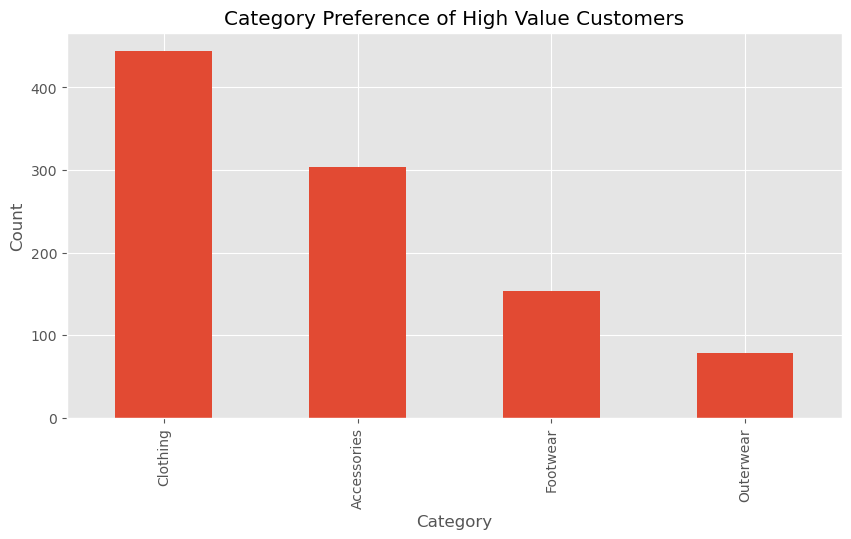

In [ ]:
# High Value Customer Category Preference
high_value_categories = high_value_customers['Category'].value_counts()

high_value_categories.plot(kind='bar', figsize=(10,5))

plt.title('Category Preference of High Value Customers')
plt.ylabel('Count')
plt.show()

In [ ]:
# Promo Dependency by Category
promo_dependency = pd.crosstab(
    df['Category'],
    df['Discount Applied'],
    normalize='index'
) * 100

promo_dependency

Discount Applied,No,Yes
Category,,
Accessories,56.209677,43.790323
Clothing,57.915947,42.084053
Footwear,56.761269,43.238731
Outerwear,55.555556,44.444444


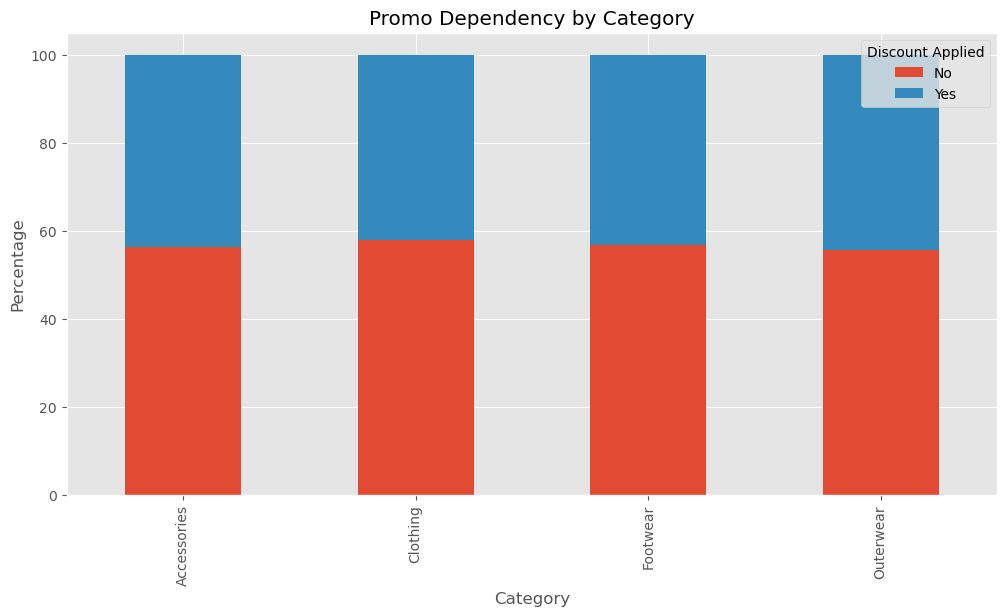

In [ ]:
# Visualize Promo Dependency
promo_dependency.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title('Promo Dependency by Category')
plt.ylabel('Percentage')
plt.show()

In [ ]:
# Geographic Revenue Analysis
geo_revenue = df.groupby('Location')['Purchase Amount (USD)'].agg(['sum','mean','count'])

geo_revenue.sort_values(by='sum', ascending=False).head(10)

,sum,mean,count
Location,,,
Montana,5784,60.250000,96
Illinois,5617,61.054348,92
California,5605,59.000000,95
Idaho,5587,60.075269,93
Nevada,5514,63.379310,87
Alabama,5261,59.112360,89
New York,5257,60.425287,87
North Dakota,5220,62.891566,83
West Virginia,5174,63.876543,81


## CUSTOMER SEGMENTATION PREVIEW

This is an initial exploratory segmentation using purchase history only. Final customer segmentation will later incorporate promotional dependency, engagement, and customer value metrics during feature enigeering.

In [ ]:
# Create Basic Customer Segments
conditions = [
    (df['Previous Purchases'] >= 40),
    (df['Previous Purchases'] >= 20),
    (df['Previous Purchases'] < 20)
]

values = ['High Loyalty', 'Medium Loyalty', 'Low Loyalty']

# Add default='Unknown' so all types match
df['Customer Segment'] = np.select(conditions, values, default='Unknown')

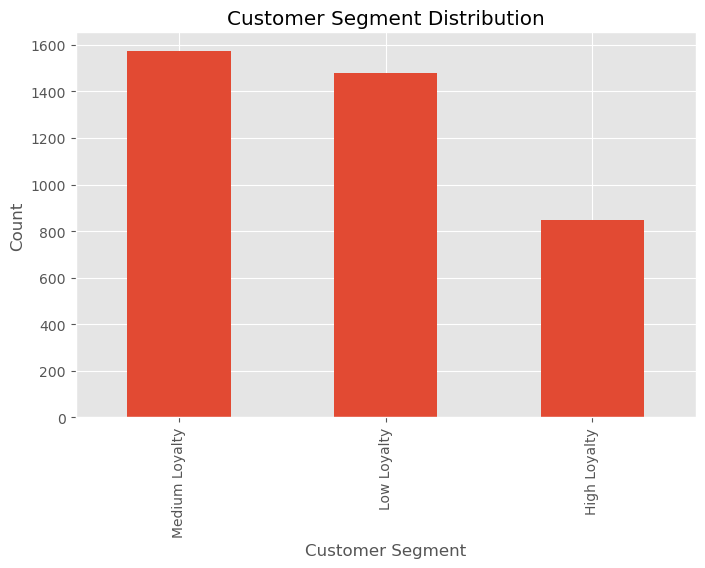

In [ ]:
# Segment Distribution
segment_counts = df['Customer Segment'].value_counts()

segment_counts.plot(kind='bar', figsize=(8,5))

plt.title('Customer Segment Distribution')
plt.ylabel('Count')
plt.show()

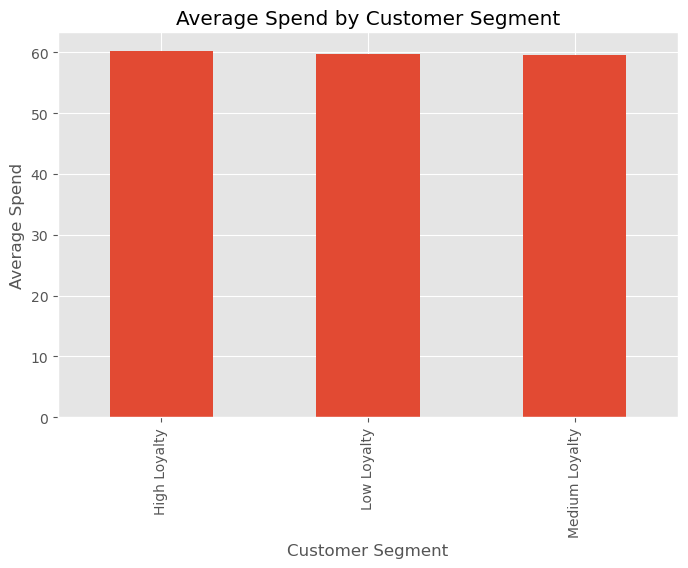

In [ ]:
# Average Spend by Segment
segment_spend = df.groupby('Customer Segment')['Purchase Amount (USD)'].mean()

segment_spend.plot(kind='bar', figsize=(8,5))

plt.title('Average Spend by Customer Segment')
plt.ylabel('Average Spend')
plt.show()

In [ ]:
# Defining Temporary Loyal Customers : 
# Identifying potential loyal customers helps establish patterns that can later inform the Ideal Customer Profile.
loyal_customers = df[
    (df['Previous Purchases'] >= 35) &
    (df['Discount Applied'] == 'No') &
    (df['Subscription Status'] == 'Yes')
]

In [ ]:
loyal_customers['Category'].value_counts()

Series([], Name: count, dtype: int64)

In [ ]:
loyal_customers['Location'].value_counts().head(10)

Series([], Name: count, dtype: int64)

## BUSINESS INSIGHTS EXTRACTION

**Objective**: Summarize key analytical findings that may support future retention, marketing, and customer strategy decisions.

In [ ]:
# Top Categories by Revenue
df.groupby('Category')['Purchase Amount (USD)'] \
    .sum() \
    .sort_values(ascending=False)

Category
Clothing       104264
Accessories     74200
Footwear        36093
Outerwear       18524
Name: Purchase Amount (USD), dtype: int64

In [ ]:
# Most Loyal Locations
df.groupby('Location')['Previous Purchases'] \
    .mean() \
    .sort_values(ascending=False) \
    .head(10)

Location
Hawaii           29.169231
Arizona          28.369231
Wyoming          28.239437
Missouri         28.148148
Alaska           28.097222
Iowa             27.608696
Alabama          27.449438
Pennsylvania     27.418919
Utah             27.169014
New Hampshire    27.098592
Name: Previous Purchases, dtype: float64

In [ ]:
location_analysis = df.groupby('Location').agg({
    'Purchase Amount (USD)': 'mean',
    'Previous Purchases': 'mean'
}).sort_values(by='Purchase Amount (USD)', ascending=False)

location_analysis.head(10)

,Purchase Amount (USD),Previous Purchases
Location,,
Alaska,67.597222,28.097222
Pennsylvania,66.567568,27.418919
Arizona,66.553846,28.369231
West Virginia,63.876543,23.555556
Nevada,63.379310,26.034483
Washington,63.328767,24.698630
North Dakota,62.891566,23.771084
Virginia,62.883117,23.506494
Utah,62.577465,27.169014


In [ ]:
# Promo Sensitive Categories
df.groupby('Category')['Discount Applied'] \
    .value_counts(normalize=True)

Category     Discount Applied
Accessories  No                  0.562097
             Yes                 0.437903
Clothing     No                  0.579159
             Yes                 0.420841
Footwear     No                  0.567613
             Yes                 0.432387
Outerwear    No                  0.555556
             Yes                 0.444444
Name: proportion, dtype: float64